## Implementation of a VBE Style Modular Addition

- https://arxiv.org/pdf/quant-ph/9511018

In [1]:
# !pip install qiskit_aer
%matplotlib inline

import sys
sys.path.append("../src")

from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit import transpile
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import math
from qiskit.circuit.library import CDKMRippleCarryAdder

### Description of the Algorithm

A modular adder circuit performs the following transformation

$$|a\rangle|b\rangle|c\rangle|N\rangle|t\rangle \mapsto |a\rangle|(a+b) \bmod N  \rangle|c\rangle|N\rangle|t\rangle$$

### 1) Adding $(a+b)$

We start with the following circuit and registers

$$|a\rangle|b\rangle|c\rangle|N\rangle|t\rangle$$


Our first step is to add the a register to the b register. Note that in modular arithmetics when adding $(a+b)$ we always perform $(a+b) \bmod 2^n$, where $n$ is the number of qubits representing $a$ and $b$. And wraps around once the highest number is reached, that can be represented by n-qubits.  

$$|a\rangle|b\rangle|c\rangle|N\rangle|t\rangle \mapsto |a\rangle|(a+b) \bmod 2^n  \rangle|c\rangle|N\rangle|t\rangle$$

### 2) Swapping the a and N register

$$ |a\rangle|(a+b) \bmod 2^n  \rangle|c\rangle|N\rangle|t\rangle \mapsto |N\rangle|(a+b) \bmod 2^n  \rangle|c\rangle|a\rangle|t\rangle$$

### 3) Subtracting N

The subtraction of N is performed to check whether 

- $a+b$ became larger than N, then we need to subtract N to get modulo N
- $a+b$ became smaller or equal to N, then we do not need to subtract and would add it back in one of the next steps

$$|N\rangle|(a+b) \bmod 2^n  \rangle|c\rangle|a\rangle|t\rangle \mapsto |N\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|t\rangle$$

### 4) Checking for overflow bit after subtracting N

To do so we need to distinguish two cases

- $a+b < N$
- $a+b \geq N$

### 4.1) $a+b<N$

We start with the first case $a+b < N$ in which scenario an overflow bit in the MSB of $b$ would be detected and the $t$ register is kept at 0 telling the circuit that the subtraction of N needs to be reversed

$$|N\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|t\rangle \mapsto |N\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|0\rangle$$

### 5.1) Writing N to the original a register, which currently holds N, to reverse subtraction

In this scenario the original a register already holds N, so no additional operation is required.

$$|N\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|0\rangle$$

### 6.1) Adding back N

N is added back 

$$|N\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|0\rangle \mapsto |N\rangle|(a+b-N+N) \bmod 2^n  \rangle|c\rangle|a\rangle|0\rangle$$

### 7.1) Uncomputing the original a register holding N

In this scenario no operation is required, since N was not changed

$$|N\rangle|(a+b) \bmod 2^n  \rangle|c\rangle|a\rangle|0\rangle \mapsto |a\rangle|(a+b) \bmod 2^n  \rangle|c\rangle|N\rangle|0\rangle$$

### 8.1) Swapping back the N and a registers

$$|N\rangle|(a+b) \bmod 2^n  \rangle|c\rangle|a\rangle|0\rangle \mapsto |a\rangle|(a+b) \bmod 2^n  \rangle|c\rangle|N\rangle|0\rangle$$

### 9.1) Subtracting a in order to uncompute the t-register

$$|a\rangle|(a+b) \bmod 2^n  \rangle|c\rangle|N\rangle|0\rangle \mapsto |a\rangle|b \bmod 2^n  \rangle|c\rangle|N\rangle|0\rangle$$

### 10.1) Uncomputing t

Note that any number that is used in modular addition, especially in Shor's alrorighm, will be due to the application of modular N always be smaller than N. Therefore, since $0 \leq a, b < N$ the subtraction of $a$ will not lead to anoverflow bit in the b register and the t register will therefore be left unchanged.

$$|a\rangle|b \bmod 2^n  \rangle|c\rangle|N\rangle|0\rangle$$

### 11.1) Uncomputing the subraction of a

$$|a\rangle|b \bmod 2^n  \rangle|c\rangle|N\rangle|0\rangle \mapsto |a\rangle|(a+b) \bmod 2^n  \rangle|c\rangle|N\rangle|0\rangle$$

Note that because in this scenario in which $(a+b)<N$ we have the final result of 

$$|a\rangle|(a+b) \bmod  N \rangle|c\rangle|N\rangle|0\rangle$$

### 4.2) $a+b \geq N$

We continue with the second case $a+b \geq N$ in which scenario no overflow bit in the MSB of $b$ would be detected and the $t$ register is set to 1 telling the circuit that the subtraction of N was corrected and therefore does not need to be reversed

$$|N\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|t\rangle \mapsto |N\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|1\rangle$$

### 5.2) Writing N to the original a register, which currently holds N, to reverse subtraction

In this scenario the original a register needs to be overridden by 0, so that N is later on not added back

$$|N\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|1\rangle \mapsto |0\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|1\rangle$$

### 6.2) Adding back Zero to the b registser

Zero is added back 

$$|0\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|1\rangle \mapsto |0\rangle|(a+b-N+0) \bmod 2^n  \rangle|c\rangle|a\rangle|1\rangle$$

### 7.2) Uncomputing the original a register holding Zero

In this scenario the original a register holding the zero is written back to N

$$|0\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|1\rangle \mapsto |N\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|N\rangle|1\rangle$$

### 8.2) Swapping back the N and a registers

$$|N\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|a\rangle|1\rangle \mapsto |a\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|N\rangle|1\rangle$$

### 9.2) Subtracting a in order to uncompute the t-register

$$|a\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|N\rangle|1\rangle \mapsto |a\rangle|b-N \bmod 2^n  \rangle|c\rangle|N\rangle|1\rangle$$

### 10.2) Uncomputing t

Note that any number that is used in modular addition, especially in Shor's alrorighm, will be due to the application of modular N always be smaller than N. Therefore, since $0 \leq a, b < N$ the subtraction of $a$ will lead to an anoverflow bit in the b register and the t register will therefore be flipped back to 0.

$$|a\rangle|b-N \bmod 2^n  \rangle|c\rangle|N\rangle|1\rangle \mapsto |a\rangle|(b-N) \bmod 2^n  \rangle|c\rangle|N\rangle|0\rangle$$

### 11.2) Uncomputing the subraction of a

$$|a\rangle|(b-N) \bmod 2^n  \rangle|c\rangle|N\rangle|0\rangle \mapsto |a\rangle|(a+b-N) \bmod 2^n  \rangle|c\rangle|N\rangle|0\rangle$$

Note that because in this scenario in which $(a+b) \geq N$ we have the final result of 

$$|a\rangle|(a+b) \bmod  N \rangle|c\rangle|N\rangle|0\rangle$$

### Now we are seting up the respective circuit

For the adder we use qiskit's CDKMRippleCarryAdder of kind "fixed"

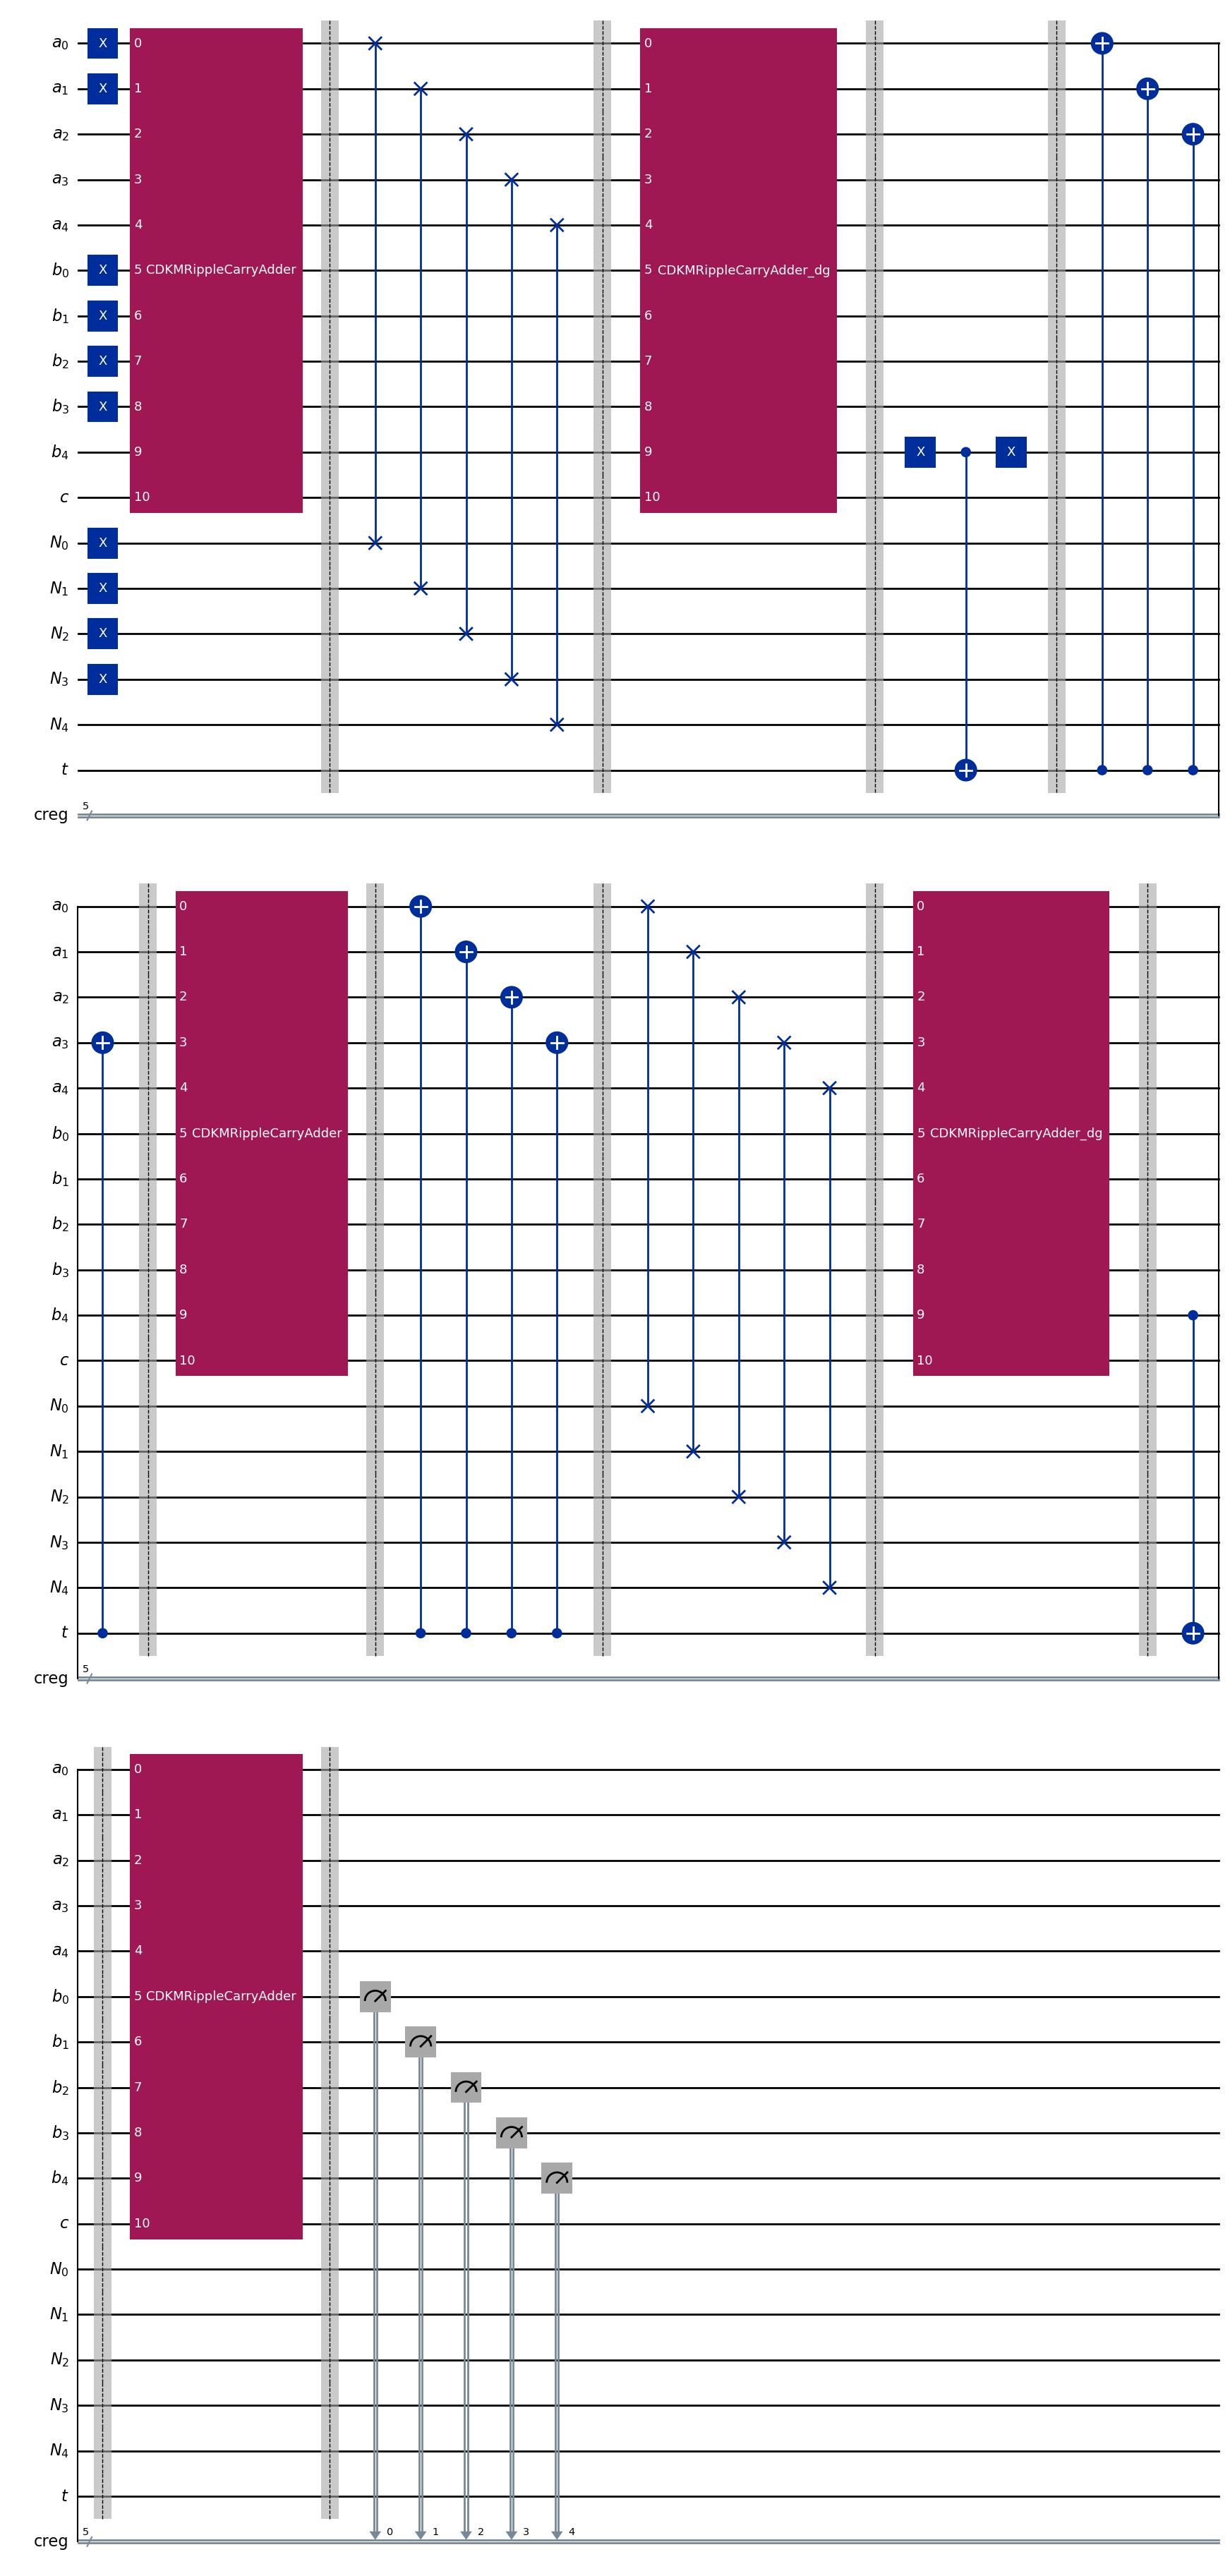

In [45]:
n = 5

a_val = 3
b_val = 15
N_val = 15

a = QuantumRegister(n, 'a') 
b = QuantumRegister(n, 'b')
c = QuantumRegister(1, 'c')
N = QuantumRegister(n, 'N')
t = QuantumRegister(1, 't')
creg = ClassicalRegister(len(b), 'creg')

qc = QuantumCircuit(a, b, c, N, t, creg) 

# Define addition gate
adder = CDKMRippleCarryAdder(n, kind="fixed").to_gate()

# Define subtraction gate
sub = adder.inverse()

# Set values for a, b and N
for i in range(n):
    if (N_val >> i) & 1:
        qc.x(N[i])
    if (a_val >> i) & 1:
        qc.x(a[i])
    if (b_val >> i) & 1:
        qc.x(b[i])

# Add a to the b register
qc.append(adder, a[:] + b[:] + c[:])

qc.barrier()

# Swap the a and N registers
for i in range(n):
    qc.swap(a[i], N[i])

qc.barrier()

# Subtract N that is now in a register
qc.append(sub, a[:] + b[:] + c[:])

qc.barrier()

# Determine whether overflow in b-register orrured and flip t register to 1
qc.x(b[n-1])
qc.cx(b[n-1], t[0])
qc.x(b[n-1])

qc.barrier()

# If a + b >= N -> MSB of b = 0, subtraction of N was correct, set a register to 0 which currently temporarily holds N
# If a + b < N -> MSB of b = 1, subtraction of N was incorrect, set a register to N to add back N
for i in range(n):
    if (N_val >> i) & 1:
        qc.cx(t[0], a[i])

qc.barrier()

# Add back N or 0 depending on state of the borrow bit t
qc.append(adder, a[:] + b[:] + c[:])

qc.barrier()

# Uncompute a register depending on state of t
for i in range(n):
   if (N_val >> i) & 1:
       qc.cx(t[0], a[i]) 

qc.barrier()
    
# Swap back a and N registers 
for i in range(n):
    qc.swap(a[i], N[i])
    
qc.barrier()

# Subtract original a
qc.append(sub, a[:] + b[:] + c[:])

qc.barrier()

# Uncompute t depending on overflow in b register
qc.cx(b[n-1], t[0])

qc.barrier()

# uncompute subtraction
qc.append(adder, a[:] + b[:] + c[:])

qc.barrier()

qc_measure = qc.copy()

# measuring b
qc_measure.measure(b, creg)

qc_measure.draw('mpl')

In [46]:
sim = AerSimulator(method="matrix_product_state")

tqc = transpile(qc_measure, sim)

nbr_shots = 2**12
result = sim.run(tqc, shots=nbr_shots).result()
counts = result.get_counts()

counts

{'00011': 4096}

In [47]:
# Simulation result
bitstring = list(counts.keys())[0]
bitstring, int(bitstring, 2)

('00011', 3)

In [48]:
# Expected classical result
(a_val + b_val) % N_val

3